In [2]:
import os
os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
os.environ['PROJ_LIB']  = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import netCDF4 as nc
import glob
import warnings
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 
warnings.filterwarnings('ignore')
print("✅ 所有库导入成功！")

✅ 所有库导入成功！


In [3]:
data_dir = os.path.expanduser('~/Final Project Computing/data/MODIS')
hdf_files = sorted(glob.glob(os.path.join(data_dir, '*.hdf')))
n_files   = len(hdf_files)
print(f"找到 {n_files} 个HDF文件")
 
# 全球grid: 3600行(90°N→90°S), 7200列(180°W→180°E), 分辨率0.05°
# 美国大陆范围: 纬度24-50°N, 经度125-66°W
lat_min, lat_max =  24,   50
lon_min, lon_max = -125, -66
 
row_start = int((90 - lat_max) / 0.05)   # 800
row_end   = int((90 - lat_min) / 0.05)   # 1320
col_start = int((lon_min + 180) / 0.05)  # 1100
col_end   = int((lon_max + 180) / 0.05)  # 2280
 
n_lat = row_end - row_start
n_lon = col_end - col_start
 
# 生成经纬度坐标
lats = np.arange(90, -90, -0.05)[row_start:row_end]
lons = np.arange(-180, 180, 0.05)[col_start:col_end]
 
print(f"网格大小: {n_lat} × {n_lon}")
print(f"纬度范围: {lats[-1]:.1f}°N ~ {lats[0]:.1f}°N")
print(f"经度范围: {lons[0]:.1f}°E ~ {lons[-1]:.1f}°E")

找到 281 个HDF文件
网格大小: 520 × 1180
纬度范围: 24.1°N ~ 50.0°N
经度范围: -125.0°E ~ -66.0°E


In [4]:
def parse_date(filepath):
    """从文件名提取年月，如 MOD10CM.A2000061 → 2000-03-01"""
    basename = os.path.basename(filepath)
    year = int(basename[9:13])
    doy  = int(basename[13:16])
    date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
    return date
 
print(f"第一个文件日期: {parse_date(hdf_files[0]).strftime('%Y-%m')}")
print(f"最后一个文件日期: {parse_date(hdf_files[-1]).strftime('%Y-%m')}")

第一个文件日期: 2000-03
最后一个文件日期: 2023-12


In [5]:
# MODIS MOD10CM 特殊值说明:
#   0-100 = 积雪覆盖百分比（有效数据）
#   211   = 夜晚
#   250   = 云覆盖
#   253   = 无法判断
#   254   = 水体
#   255   = 填充值（无数据）
INVALID = [211, 250, 253, 254, 255]
 
snow_all = np.full((n_files, n_lat, n_lon), np.nan, dtype=np.float32)
dates    = []
 
print("开始读取文件...")
for i, fpath in enumerate(hdf_files):
    f   = nc.Dataset(fpath, 'r')
    raw = f.variables['Snow_Cover_Monthly_CMG'][row_start:row_end, col_start:col_end]
    f.close()
 
    data = np.array(raw, dtype=np.float32)
    for val in INVALID:
        data[data == val] = np.nan
    data[data > 100] = np.nan   # 额外保险
 
    snow_all[i] = data
    dates.append(parse_date(fpath))
 
    if (i + 1) % 50 == 0:
        print(f"  已处理 {i+1}/{n_files} 个文件")
 
dates = pd.DatetimeIndex(dates)
 
# 验证
print(f"\n✅ 读取完成！")
print(f"数组形状: {snow_all.shape}  (时间, 纬度, 经度)")
print(f"NaN比例:  {np.isnan(snow_all[0]).mean():.2%}  （海洋+无效区域）")
print(f"数值范围: {np.nanmin(snow_all):.1f} ~ {np.nanmax(snow_all):.1f} %")

开始读取文件...
  已处理 50/281 个文件
  已处理 100/281 个文件
  已处理 150/281 个文件
  已处理 200/281 个文件
  已处理 250/281 个文件

✅ 读取完成！
数组形状: (281, 520, 1180)  (时间, 纬度, 经度)
NaN比例:  31.62%  （海洋+无效区域）
数值范围: 0.0 ~ 100.0 %


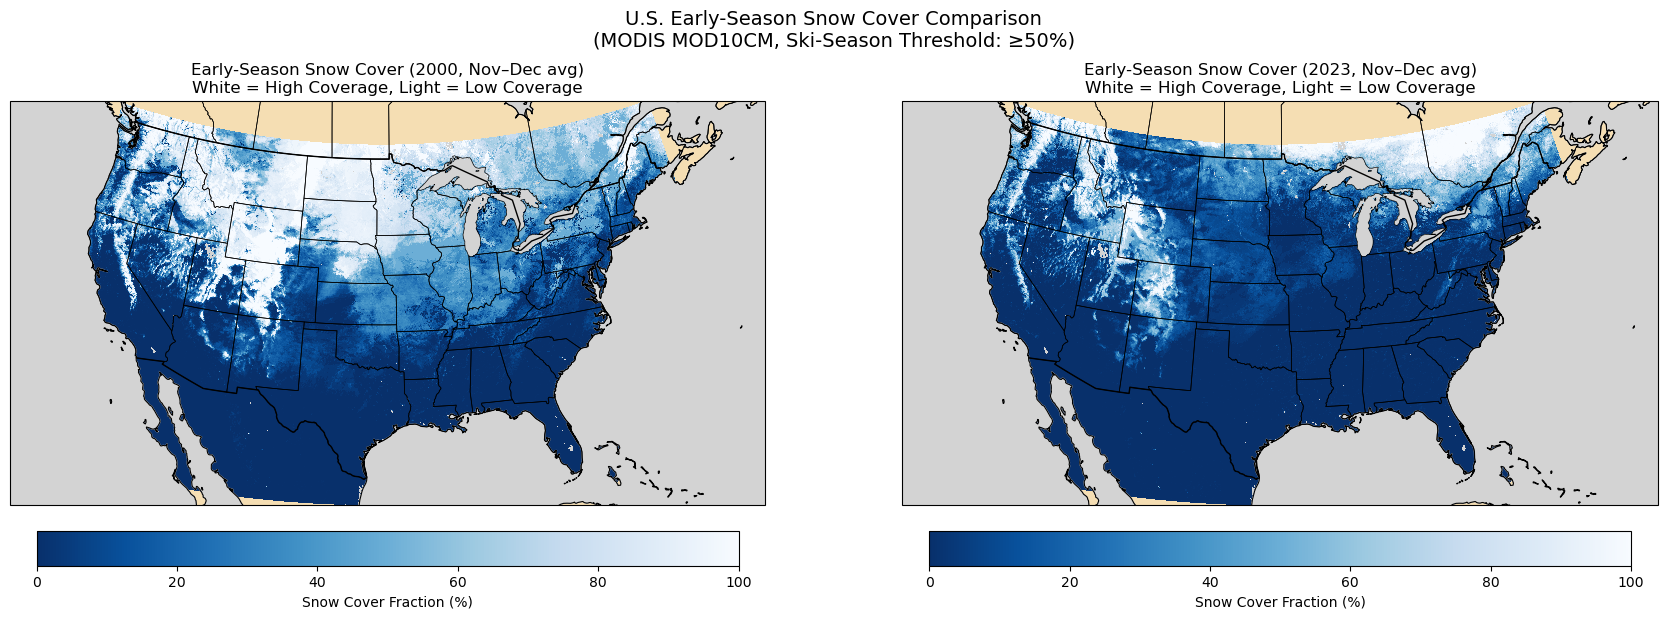

In [7]:
# 选11月和12月数据（早季）
idx_2000_nov = np.where((dates.year == 2000) & (dates.month == 11))[0]
idx_2023_nov = np.where((dates.year == 2023) & (dates.month == 11))[0]
idx_2000_dec = np.where((dates.year == 2000) & (dates.month == 12))[0]
idx_2023_dec = np.where((dates.year == 2023) & (dates.month == 12))[0]

# 用11-12月平均
snow_2000_early = np.nanmean(snow_all[np.concatenate([idx_2000_nov, idx_2000_dec])], axis=0)
snow_2023_early = np.nanmean(snow_all[np.concatenate([idx_2023_nov, idx_2023_dec])], axis=0)

SKI_THRESHOLD = 50  # ≥50% 视为可滑雪覆盖

cmap_snow = plt.cm.Blues_r
cmap_snow.set_bad(color='lightgray')

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

for ax, data, year in zip(axes, [snow_2000_early, snow_2023_early], [2000, 2023]):
    im = ax.pcolormesh(lons, lats, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_snow, vmin=0, vmax=100)
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.LAND,      color='wheat',     zorder=0)
    ax.add_feature(cfeature.STATES,    linewidth=0.5,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(f'Early-Season Snow Cover ({year}, Nov–Dec avg)\n'
                 f'White = High Coverage, Light = Low Coverage', fontsize=12)
    plt.colorbar(im, ax=ax, label='Snow Cover Fraction (%)',
                 orientation='horizontal', pad=0.05, shrink=0.8)

plt.suptitle('U.S. Early-Season Snow Cover Comparison\n'
             f'(MODIS MOD10CM, Ski-Season Threshold: ≥{SKI_THRESHOLD}%)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snow_comparison_early_season.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Cell 6: 计算每年11-12月平均积雪 ──
years = np.arange(2000, 2024)
early_season_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)

for i, yr in enumerate(years):
    mask = (dates.year == yr) & (dates.month.isin([11, 12]))
    if mask.sum() > 0:
        early_season_annual[i] = np.nanmean(snow_all[mask], axis=0)

print(f"✅ Done! Shape: {early_season_annual.shape}")
print(f"Years with data: {np.sum(~np.all(np.isnan(early_season_annual), axis=(1,2)))}")

# ── Cell 7: 逐像素线性趋势 ──
from scipy import stats

print("Computing trend map, please wait (~1-2 min)...")

slope_map = np.full((n_lat, n_lon), np.nan)
pval_map  = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        y     = early_season_annual[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope, _, _, pval, _ = stats.linregress(years[valid], y[valid])
            slope_map[i, j] = slope
            pval_map[i, j]  = pval

print(f"✅ Done! Trend range: {np.nanmin(slope_map):.3f} ~ {np.nanmax(slope_map):.3f} %/year")

✅ Done! Shape: (24, 520, 1180)
Years with data: 24
Computing trend map, please wait (~1-2 min)...
✅ Done! Trend range: -2.274 ~ 2.596 %/year


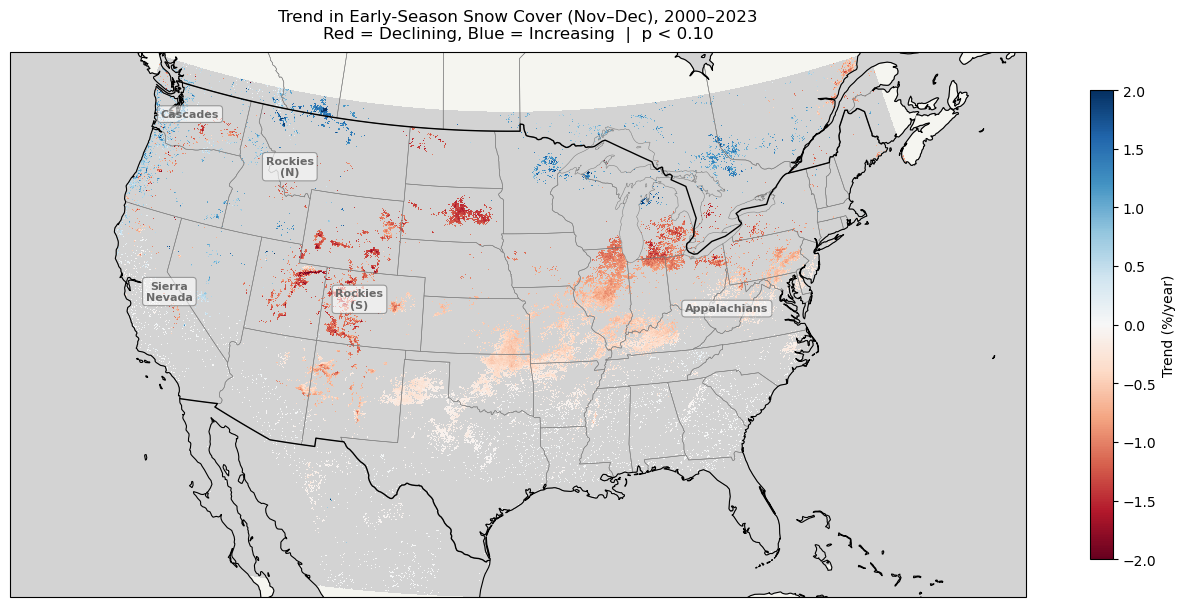

In [18]:
# ── Cell 8: Early-Season Snow Cover Trend Map ──
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

slope_sig = np.where(pval_map < 0.10, slope_map, np.nan)

cmap_trend = plt.cm.RdBu
cmap_trend.set_bad(color='lightgray')

fig, ax = plt.subplots(figsize=(13, 7),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

im = ax.pcolormesh(lons, lats, slope_sig,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap_trend, vmin=-2, vmax=2)

ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
ax.add_feature(cfeature.LAND,      color='#f5f5f0',   zorder=0)
ax.add_feature(cfeature.STATES,    linewidth=0.4,     zorder=2, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)

# 手动标注主要山脉（lon, lat, 名称）
mountain_labels = {
    'Cascades':        (-121.5, 47.5),
    'Sierra\nNevada':  (-119.5, 38.0),
    'Rockies\n(N)':    (-113.0, 46.0),
    'Rockies\n(S)':    (-106.5, 39.5),
    'Appalachians':    (-81.0,  38.5),
}

for name, (lon, lat) in mountain_labels.items():
    ax.text(lon, lat, name,
            transform=ccrs.PlateCarree(),
            fontsize=8, fontweight='bold',
            color='dimgray', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.6,
                      edgecolor='dimgray', boxstyle='round,pad=0.3',
                      linewidth=0.8))

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.set_title(
    'Trend in Early-Season Snow Cover (Nov–Dec), 2000–2023\n'
    'Red = Declining, Blue = Increasing  |  p < 0.10',
    fontsize=12, pad=10)

plt.colorbar(im, ax=ax, label='Trend (%/year)', shrink=0.7)

plt.tight_layout()
plt.savefig('early_season_trend_map.png', dpi=150, bbox_inches='tight')
plt.show()

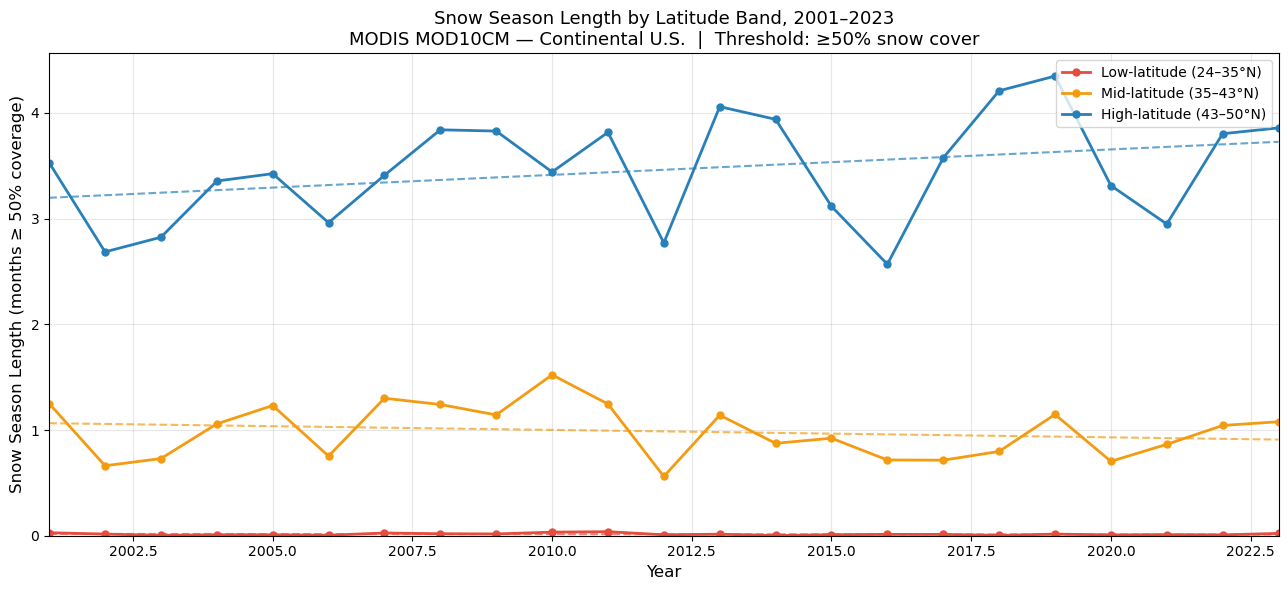

In [27]:
# ── Snow Season Length by Latitude Band ──
SKI_THRESHOLD = 50
years_full = np.arange(2000, 2024)
years_plot = years_full[1:]  # 2001-2023，跳过2000

# 计算每年每格点的积雪季节长度
season_length = np.full((len(years_full), n_lat, n_lon), np.nan, dtype=np.float32)

for i, yr in enumerate(years_full):
    mask    = dates.year == yr
    yr_data = snow_all[mask]
    if mask.sum() == 0:
        continue
    sl      = np.nansum(yr_data >= SKI_THRESHOLD, axis=0).astype(np.float32)
    all_nan = np.all(np.isnan(yr_data), axis=0)
    sl[all_nan] = np.nan
    season_length[i] = sl

regions = {
    'Low-latitude (24–35°N)':  (lats >= 24) & (lats < 35),
    'Mid-latitude (35–43°N)':  (lats >= 35) & (lats < 43),
    'High-latitude (43–50°N)': (lats >= 43) & (lats <= 50),
}
colors = ['#e74c3c', '#f39c12', '#2980b9']

fig, ax = plt.subplots(figsize=(13, 6))

for (label, lat_mask), color in zip(regions.items(), colors):
    ts = np.array([
        np.nanmean(season_length[i, lat_mask, :])
        for i in range(1, len(years_full))
    ])

    ax.plot(years_plot, ts, 'o-', color=color,
            label=label, linewidth=2, markersize=5)

    valid = ~np.isnan(ts)
    if valid.sum() >= 5:
        slope, intercept, _, _, _ = stats.linregress(
            years_plot[valid], ts[valid])
        ax.plot(years_plot, slope * years_plot + intercept,
                '--', color=color, alpha=0.7, linewidth=1.5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Snow Season Length (months ≥ 50% coverage)', fontsize=12)
ax.set_title('Snow Season Length by Latitude Band, 2001–2023\n'
             'MODIS MOD10CM — Continental U.S.  |  Threshold: ≥50% snow cover',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(2001, 2023)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('season_length_by_latitude.png', dpi=150, bbox_inches='tight')
plt.show()

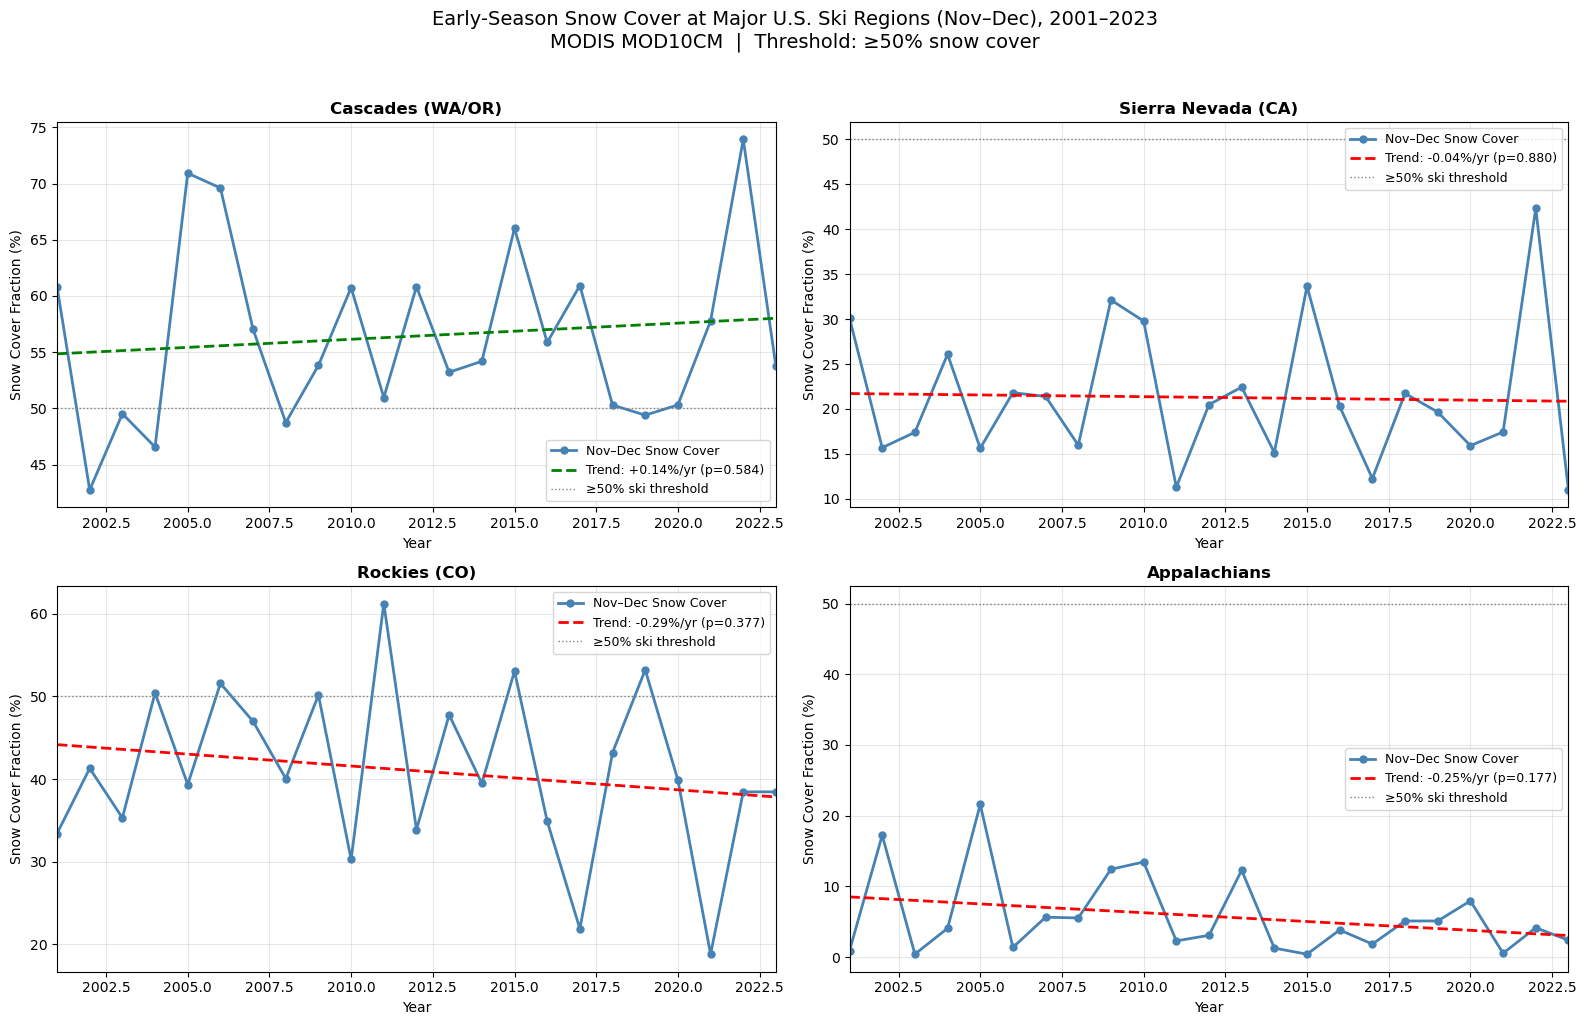

Saved: ski_early_season_timeseries.png


In [29]:
# ── Early-Season Snow Cover at Major Ski Regions ──
years = np.arange(2000, 2024)
years_plot = years[1:]  # 2001-2023，跳过2000

# 早季数据（11-12月平均）
early_season_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)
for i, yr in enumerate(years):
    mask = (dates.year == yr) & (dates.month.isin([11, 12]))
    if mask.sum() > 0:
        early_season_annual[i] = np.nanmean(snow_all[mask], axis=0)

# 定义主要滑雪区域
ski_regions = {
    'Cascades (WA/OR)':   {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada (CA)': {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies (CO)':       {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians':       {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (region_name, bounds) in zip(axes, ski_regions.items()):
    lat_mask = (lats >= bounds['lat'][0]) & (lats <= bounds['lat'][1])
    lon_mask = (lons >= bounds['lon'][0]) & (lons <= bounds['lon'][1])

    ts = np.array([
        np.nanmean(early_season_annual[i][np.ix_(lat_mask, lon_mask)])
        for i in range(1, len(years))  # 跳过2000
    ])

    ax.plot(years_plot, ts, 'o-', color='steelblue',
            linewidth=2, markersize=5, label='Nov–Dec Snow Cover')

    valid = ~np.isnan(ts)
    if valid.sum() >= 5:
        slope, intercept, r, p, _ = stats.linregress(years_plot[valid], ts[valid])
        line_color = 'red' if slope < 0 else 'green'
        ax.plot(years_plot, slope * years_plot + intercept,
                '--', color=line_color, linewidth=2,
                label=f'Trend: {slope:+.2f}%/yr (p={p:.3f})')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Snow Cover Fraction (%)', fontsize=10)
    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1,
               label='≥50% ski threshold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2001, 2023)

plt.suptitle('Early-Season Snow Cover at Major U.S. Ski Regions (Nov–Dec), 2001–2023\n'
             'MODIS MOD10CM  |  Threshold: ≥50% snow cover',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ski_early_season_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ski_early_season_timeseries.png")

# Hypothesis 3

In [30]:
# ── Cell 12: 批量计算湿球温度 & 统计造雪小时数 ──
import xarray as xr
import numpy as np
import os
import glob

era5_dir = os.path.expanduser('~/Final Project Computing/data/ERA5')
era5_files = sorted(glob.glob(f'{era5_dir}/era5_hourly_*.nc'))

# 湿球温度公式 (Stull 2011)
def wet_bulb(T_C, Td_C):
    """输入摄氏度，输出湿球温度（摄氏度）"""
    RH = 100 * np.exp((17.625 * Td_C) / (243.04 + Td_C)) / \
              np.exp((17.625 * T_C)  / (243.04 + T_C))
    RH = np.clip(RH, 0.1, 100)
    Tw = (T_C * np.arctan(0.151977 * (RH + 8.313659)**0.5)
        + np.arctan(T_C + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035)
    return Tw

# 用第一个文件获取经纬度坐标
ds0 = xr.open_dataset(era5_files[0])
era5_lats = ds0.latitude.values
era5_lons = ds0.longitude.values
ds0.close()

years_era5 = list(range(2000, 2026))
n_years    = len(years_era5)
n_lat_e    = len(era5_lats)
n_lon_e    = len(era5_lons)

# 存储每年11-12月造雪小时数（湿球温度 < -2°C 的小时数）
snowmaking_hours = np.full((n_years, n_lat_e, n_lon_e), np.nan, dtype=np.float32)

print("开始计算湿球温度...")
for i, (yr, fpath) in enumerate(zip(years_era5, era5_files)):
    ds = xr.open_dataset(fpath)

    # K → °C
    T_C  = ds['t2m'].values - 273.15
    Td_C = ds['d2m'].values - 273.15
    ds.close()

    # 计算湿球温度 (time, lat, lon)
    Tw = wet_bulb(T_C, Td_C)

    # 统计Tw < -2°C 的小时数
    snowmaking_hours[i] = np.sum(Tw < -2, axis=0).astype(np.float32)

    print(f"  {yr}: 完成，最大造雪小时数={np.nanmax(snowmaking_hours[i]):.0f}h")

print(f"\n✅ 全部完成！数组形状: {snowmaking_hours.shape}")

开始计算湿球温度...
  2000: 完成，最大造雪小时数=1464h
  2001: 完成，最大造雪小时数=1422h
  2002: 完成，最大造雪小时数=1460h
  2003: 完成，最大造雪小时数=1462h
  2004: 完成，最大造雪小时数=1424h
  2005: 完成，最大造雪小时数=1416h
  2006: 完成，最大造雪小时数=1434h
  2007: 完成，最大造雪小时数=1398h
  2008: 完成，最大造雪小时数=1403h
  2009: 完成，最大造雪小时数=1418h
  2010: 完成，最大造雪小时数=1415h
  2011: 完成，最大造雪小时数=1460h
  2012: 完成，最大造雪小时数=1403h
  2013: 完成，最大造雪小时数=1454h
  2014: 完成，最大造雪小时数=1409h
  2015: 完成，最大造雪小时数=1431h
  2016: 完成，最大造雪小时数=1348h
  2017: 完成，最大造雪小时数=1414h
  2018: 完成，最大造雪小时数=1454h
  2019: 完成，最大造雪小时数=1453h
  2020: 完成，最大造雪小时数=1405h
  2021: 完成，最大造雪小时数=1364h
  2022: 完成，最大造雪小时数=1456h
  2023: 完成，最大造雪小时数=1397h
  2024: 完成，最大造雪小时数=1439h
  2025: 完成，最大造雪小时数=1319h

✅ 全部完成！数组形状: (26, 105, 237)


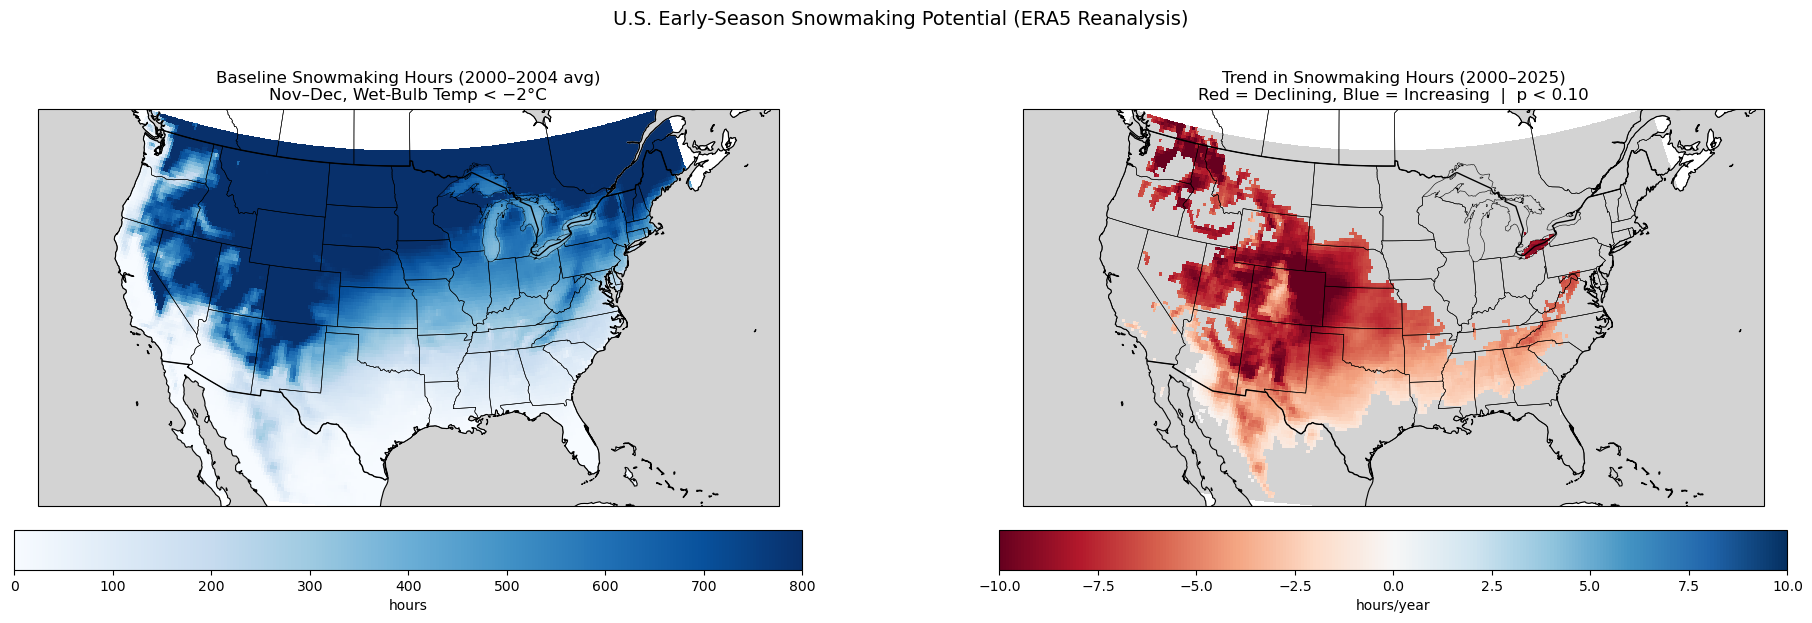

Saved: snowmaking_trend.png


In [31]:
# ── Cell 13: Snowmaking Hours Trend Map ──
from scipy import stats

years_era5_arr = np.array(years_era5)

# 逐像素趋势
slope_sm = np.full((n_lat_e, n_lon_e), np.nan)
pval_sm  = np.full((n_lat_e, n_lon_e), np.nan)
for i in range(n_lat_e):
    for j in range(n_lon_e):
        y, valid = snowmaking_hours[:, i, j], ~np.isnan(snowmaking_hours[:, i, j])
        if valid.sum() >= 10:
            slope_sm[i,j], _, _, pval_sm[i,j], _ = stats.linregress(years_era5_arr[valid], y[valid])

slope_sig = np.where(pval_sm < 0.10, slope_sm, np.nan)

# 画图
fig, axes = plt.subplots(1, 2, figsize=(20, 6),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-96, central_latitude=39)})

plots = [
    (axes[0], np.nanmean(snowmaking_hours[:5], axis=0),
     'Blues', 0, 800, 'hours', 'Baseline Snowmaking Hours (2000–2004 avg)\nNov–Dec, Wet-Bulb Temp < −2°C'),
    (axes[1], slope_sig,
     'RdBu',  -10, 10, 'hours/year', 'Trend in Snowmaking Hours (2000–2025)\nRed = Declining, Blue = Increasing  |  p < 0.10'),
]

for ax, data, cmap, vmin, vmax, clabel, title in plots:
    cmap_use = plt.cm.get_cmap(cmap)
    cmap_use.set_bad(color='lightgray')
    im = ax.pcolormesh(era5_lons, era5_lats, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_use, vmin=vmin, vmax=vmax)
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.STATES,    linewidth=0.4,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, label=clabel, orientation='horizontal', pad=0.05, shrink=0.8)

plt.suptitle('U.S. Early-Season Snowmaking Potential (ERA5 Reanalysis)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snowmaking_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: snowmaking_trend.png")

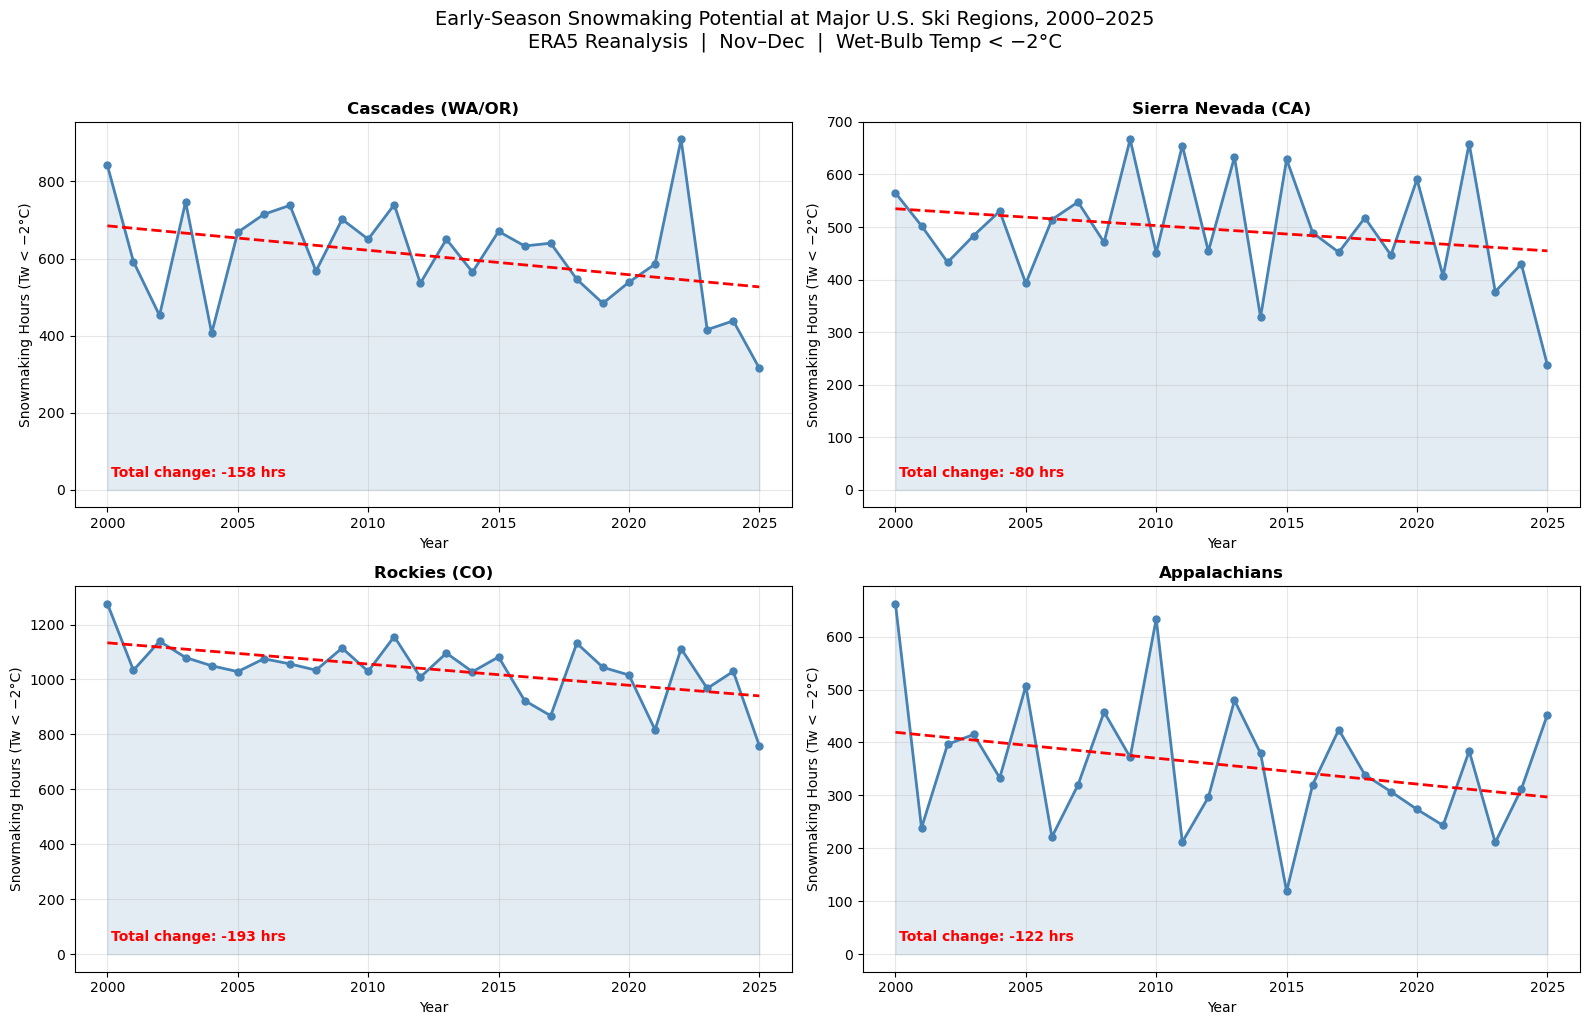

Saved: snowmaking_timeseries.png


In [32]:
# ── Cell 14: Snowmaking Hours Time Series at Major Ski Regions ──
years_era5_arr = np.array(years_era5)

ski_regions_era5 = {
    'Cascades (WA/OR)':   {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada (CA)': {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies (CO)':       {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians':       {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (region_name, bounds) in zip(axes.flatten(), ski_regions_era5.items()):
    lat_mask = (era5_lats >= bounds['lat'][0]) & (era5_lats <= bounds['lat'][1])
    lon_mask = (era5_lons >= bounds['lon'][0]) & (era5_lons <= bounds['lon'][1])

    ts    = np.array([np.nanmean(snowmaking_hours[i][np.ix_(lat_mask, lon_mask)])
                      for i in range(n_years)])
    valid = ~np.isnan(ts)
    slope, intercept, _, p, _ = stats.linregress(years_era5_arr[valid], ts[valid])
    line_color    = 'red' if slope < 0 else 'green'
    total_change  = slope * (years_era5_arr[-1] - years_era5_arr[0])

    ax.plot(years_era5_arr, ts, 'o-', color='steelblue', linewidth=2, markersize=5)
    ax.fill_between(years_era5_arr, ts, alpha=0.15, color='steelblue')
    ax.plot(years_era5_arr, slope * years_era5_arr + intercept,
            '--', color=line_color, linewidth=2)
    ax.annotate(f'Total change: {total_change:+.0f} hrs',
                xy=(0.05, 0.08), xycoords='axes fraction',
                fontsize=10, color=line_color, fontweight='bold')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Snowmaking Hours (Tw < −2°C)', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Early-Season Snowmaking Potential at Major U.S. Ski Regions, 2000–2025\n'
             'ERA5 Reanalysis  |  Nov–Dec  |  Wet-Bulb Temp < −2°C',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snowmaking_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: snowmaking_timeseries.png")

In [36]:
# ── Step 1: 生成各区域MODIS分辨率海拔值 ──
import rasterio
from rasterio.merge import merge
import numpy as np
import glob

dem_dir = os.path.expanduser('~/Final Project Computing/data/DEM')

# 存储每个区域的MODIS分辨率海拔值
region_elev = {}  # {name: {'lat_idx', 'lon_idx', 'elev_2d'}}

for name, bounds in ski_regions.items():
    lat_lo, lat_hi = bounds['lat']
    lon_lo, lon_hi = bounds['lon']

    # 找tiles
    region_tiles = []
    for lat in range(lat_lo, lat_hi + 1):
        for lon in range(abs(lon_hi), abs(lon_lo) + 1):
            found = glob.glob(f"{dem_dir}/*N{lat:02d}_00_W{lon:03d}_00_DEM.tif")
            region_tiles.extend(found)

    src_files = [rasterio.open(f) for f in region_tiles]
    mosaic, _ = merge(src_files)
    for s in src_files:
        s.close()

    elev_raw = mosaic[0].astype(np.float32)
    elev_raw[elev_raw < -100] = np.nan

    n_rows, n_cols = elev_raw.shape
    elev_lats = np.linspace(lat_hi, lat_lo, n_rows)
    elev_lons = np.linspace(lon_lo, lon_hi, n_cols)

    lat_idx = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
    lon_idx = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]

    # 每个MODIS格点的平均海拔
    elev_2d = np.full((len(lat_idx), len(lon_idx)), np.nan)
    for ii, li in enumerate(lat_idx):
        for jj, lj in enumerate(lon_idx):
            dlat = np.abs(elev_lats - lats[li]) < 0.025
            dlon = np.abs(elev_lons - lons[lj]) < 0.025
            patch = elev_raw[np.ix_(dlat, dlon)]
            elev_2d[ii, jj] = np.nanmean(patch) if patch.size > 0 else np.nan

    region_elev[name] = {
        'lat_idx': lat_idx,
        'lon_idx': lon_idx,
        'elev_2d': elev_2d
    }
    print(f"✅ {name}: 海拔范围 {np.nanmin(elev_2d):.0f}m ~ {np.nanmax(elev_2d):.0f}m")

✅ Cascades (WA/OR): 海拔范围 14m ~ 2958m
✅ Sierra Nevada (CA): 海拔范围 -11m ~ 3738m
✅ Rockies (CO): 海拔范围 1123m ~ 3830m
✅ Appalachians: 海拔范围 -0m ~ 1433m


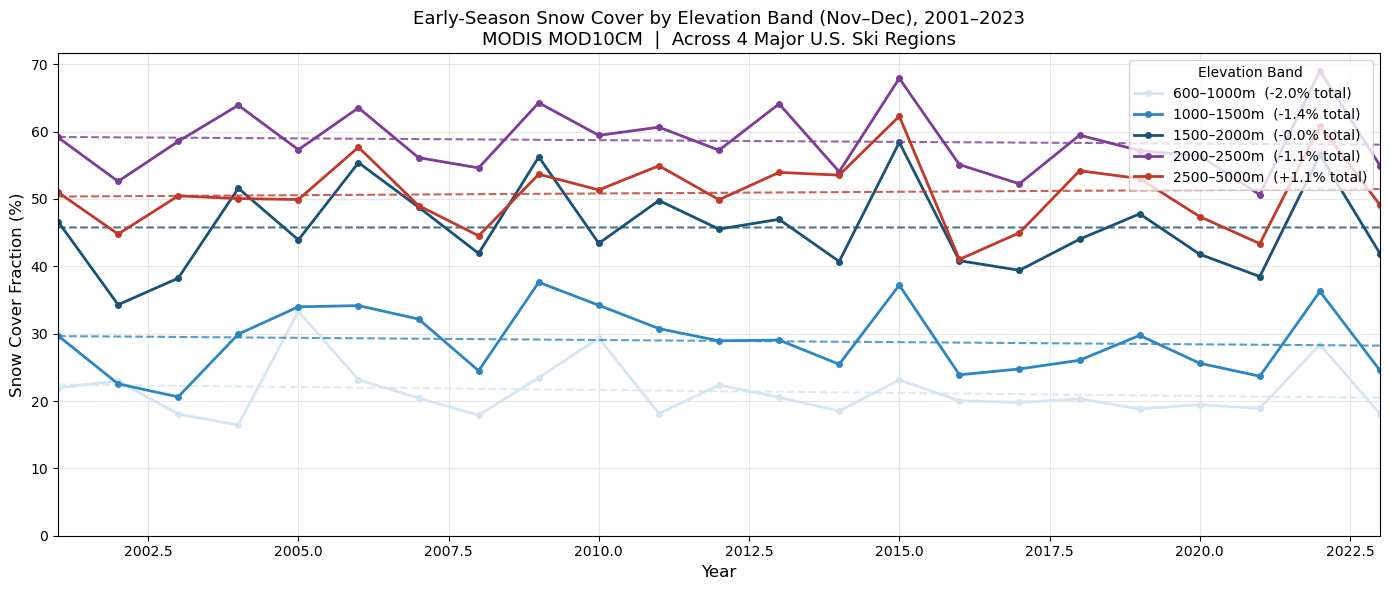

Saved: snow_by_elevation_band.png


In [38]:
# ── Step 2: 按海拔段计算早季积雪时序 ──
elev_bands = [
    ( 600, 1000, '#d4e6f1'),
    (1000, 1500, '#2e86c1'),
    (1500, 2000, '#1a5276'),
    (2000, 2500, '#7d3c98'),
    (2500, 5000, '#c0392b'),
]

fig, ax = plt.subplots(figsize=(14, 6))

for (e_lo, e_hi, color) in elev_bands:
    # 汇总所有区域中属于这个海拔段的像素
    ts_all_years = []
    for i in range(1, len(years)):  # 跳过2000
        vals = []
        for name, info in region_elev.items():
            li   = info['lat_idx']
            lj   = info['lon_idx']
            emask = (info['elev_2d'] >= e_lo) & (info['elev_2d'] < e_hi)
            if emask.sum() == 0:
                continue
            patch = early_season_annual[i][np.ix_(li, lj)]
            vals.append(np.nanmean(patch[emask]))
        ts_all_years.append(np.nanmean(vals) if vals else np.nan)

    ts = np.array(ts_all_years)
    valid = ~np.isnan(ts)
    if valid.sum() < 5:
        continue

    slope, intercept, _, _, _ = stats.linregress(years_plot[valid], ts[valid])
    total = slope * (years_plot[-1] - years_plot[0])

    label = f'{e_lo}–{e_hi}m  ({total:+.1f}% total)'
    ax.plot(years_plot, ts, 'o-', color=color,
            linewidth=2, markersize=4, label=label)
    ax.plot(years_plot, slope * years_plot + intercept,
            '--', color=color, linewidth=1.5, alpha=0.8)
    
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Snow Cover Fraction (%)', fontsize=12)
ax.set_title('Early-Season Snow Cover by Elevation Band (Nov–Dec), 2001–2023\n'
             'MODIS MOD10CM  |  Across 4 Major U.S. Ski Regions',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right', title='Elevation Band')
ax.grid(True, alpha=0.3)
ax.set_xlim(2001, 2023)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('snow_by_elevation_band.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: snow_by_elevation_band.png")